# Capítulo 3 — Fundamentos matemáticos

Este notebook acompaña al capítulo 3 del libro. Tiene tres partes:

1. **Descenso del gradiente desde cero en NumPy** para regresión lineal.
2. **MSE frente a log-verosimilitud negativa**: comprobación numérica de que el MSE es, salvo constantes, la log-verosimilitud negativa de un modelo gaussiano.
3. **Regularización Ridge y Lasso**: efecto del coeficiente de regularización sobre los parámetros aprendidos.

El núcleo se implementa con NumPy; al final se contrasta con scikit-learn.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.RandomState(0)

## 1. Descenso del gradiente desde cero para regresión lineal

Generamos datos sintéticos de un modelo lineal con ruido gaussiano:
$y = w_{\mathrm{real}}\, x + b_{\mathrm{real}} + \varepsilon$.

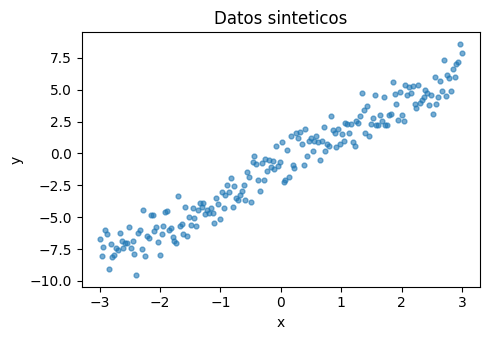

In [2]:
n = 200
x = np.linspace(-3, 3, n)
w_real, b_real = 2.5, -1.0
ruido = rng.normal(0.0, 1.0, size=n)
y = w_real * x + b_real + ruido

plt.figure(figsize=(5, 3.5))
plt.scatter(x, y, s=12, alpha=0.6)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Datos sinteticos')
plt.tight_layout()
plt.show()

El MSE para parámetros $(w, b)$ es
$\mathcal{L}(w,b) = \frac{1}{n}\sum_i (w x_i + b - y_i)^2$,
con gradientes
$\partial_w \mathcal{L} = \frac{2}{n}\sum_i (w x_i + b - y_i)\, x_i$ y
$\partial_b \mathcal{L} = \frac{2}{n}\sum_i (w x_i + b - y_i)$.

In [3]:
def mse(w, b, x, y):
    residuo = w * x + b - y
    return np.mean(residuo ** 2)

def gradiente_mse(w, b, x, y):
    residuo = w * x + b - y
    grad_w = 2.0 * np.mean(residuo * x)
    grad_b = 2.0 * np.mean(residuo)
    return grad_w, grad_b

def descenso_gradiente(x, y, tasa=0.05, n_pasos=200, w0=0.0, b0=0.0):
    w, b = w0, b0
    historia = []
    for paso in range(n_pasos):
        grad_w, grad_b = gradiente_mse(w, b, x, y)
        w -= tasa * grad_w
        b -= tasa * grad_b
        historia.append(mse(w, b, x, y))
    return w, b, np.array(historia)

w_ajuste, b_ajuste, historia = descenso_gradiente(x, y)
print('w ajustado:', round(w_ajuste, 4), ' (real:', w_real, ')')
print('b ajustado:', round(b_ajuste, 4), ' (real:', b_real, ')')

w ajustado: 2.4689  (real: 2.5 )
b ajustado: -0.9291  (real: -1.0 )


w (minimos cuadrados): 2.4689
b (minimos cuadrados): -0.9291


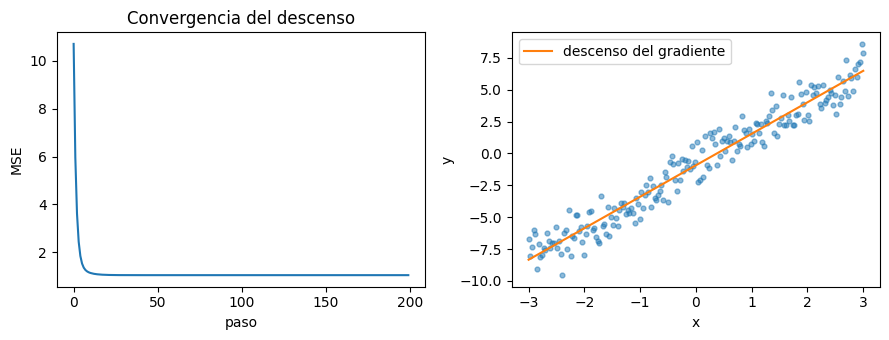

In [4]:
# Solucion exacta por minimos cuadrados para comparar
A = np.vstack([x, np.ones_like(x)]).T
w_ols, b_ols = np.linalg.lstsq(A, y, rcond=None)[0]
print('w (minimos cuadrados):', round(w_ols, 4))
print('b (minimos cuadrados):', round(b_ols, 4))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
ax1.plot(historia)
ax1.set_xlabel('paso')
ax1.set_ylabel('MSE')
ax1.set_title('Convergencia del descenso')
ax2.scatter(x, y, s=12, alpha=0.5)
ax2.plot(x, w_ajuste * x + b_ajuste, color='C1', label='descenso del gradiente')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.legend()
plt.tight_layout()
plt.show()

## 2. MSE frente a log-verosimilitud negativa

Bajo un modelo $y_i = w x_i + b + \varepsilon_i$ con $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$, la log-verosimilitud negativa es

$$-\log p(\mathcal{D}\mid w, b) = \frac{n}{2}\log(2\pi\sigma^2) + \frac{1}{2\sigma^2}\sum_i (w x_i + b - y_i)^2.$$

Como función de $(w, b)$, esto es el MSE multiplicado por una constante positiva más un término independiente de los parámetros. Comprobémoslo numéricamente.

In [5]:
def log_verosimilitud_negativa(w, b, x, y, sigma=1.0):
    n_datos = len(x)
    residuo = w * x + b - y
    termino_const = 0.5 * n_datos * np.log(2.0 * np.pi * sigma ** 2)
    termino_datos = np.sum(residuo ** 2) / (2.0 * sigma ** 2)
    return termino_const + termino_datos

# Barremos w fijando b en su valor ajustado y comparamos las dos curvas
valores_w = np.linspace(w_real - 2, w_real + 2, 100)
curva_mse = np.array([mse(wv, b_ajuste, x, y) for wv in valores_w])
curva_nll = np.array([log_verosimilitud_negativa(wv, b_ajuste, x, y) for wv in valores_w])

# El MSE reescalado: NLL = (n / 2) * MSE + const   (con sigma = 1)
mse_reescalado = (n / 2.0) * curva_mse + (curva_nll[0] - (n / 2.0) * curva_mse[0])
diferencia_maxima = np.max(np.abs(mse_reescalado - curva_nll))
print('Diferencia maxima tras reescalar:', diferencia_maxima)
print('Minimo del MSE en w =', round(valores_w[np.argmin(curva_mse)], 3))
print('Minimo de la NLL en w =', round(valores_w[np.argmin(curva_nll)], 3))

Diferencia maxima tras reescalar: 2.2737367544323206e-13
Minimo del MSE en w = 2.48
Minimo de la NLL en w = 2.48


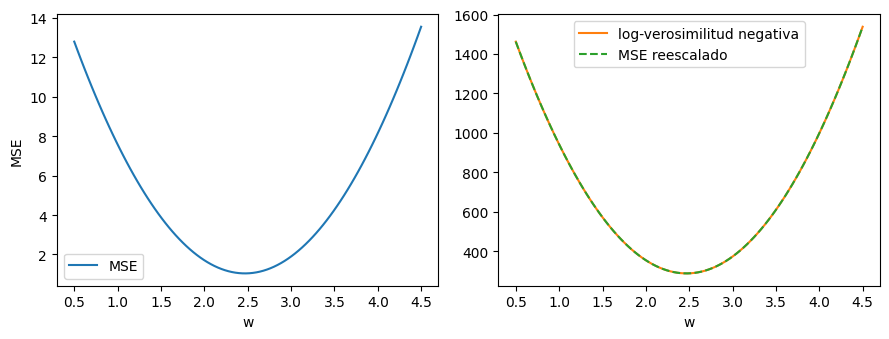

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
ax1.plot(valores_w, curva_mse, label='MSE')
ax1.set_xlabel('w')
ax1.set_ylabel('MSE')
ax1.legend()
ax2.plot(valores_w, curva_nll, color='C1', label='log-verosimilitud negativa')
ax2.plot(valores_w, mse_reescalado, '--', color='C2', label='MSE reescalado')
ax2.set_xlabel('w')
ax2.legend()
plt.tight_layout()
plt.show()

Las dos curvas tienen el mismo mínimo y, tras reescalar, coinciden: minimizar el MSE es equivalente a maximizar la verosimilitud bajo ruido gaussiano de varianza fija.

## 3. Efecto de Ridge y Lasso sobre los parámetros aprendidos

Construimos un problema con varias variables, algunas irrelevantes y otras correlacionadas, y observamos cómo la intensidad de la regularización $\alpha$ modifica los coeficientes: Ridge los encoge de forma continua hacia cero; Lasso los anula exactamente (selección de variables).

In [7]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

n_muestras, n_variables = 100, 8
X = rng.normal(size=(n_muestras, n_variables))
# Solo las tres primeras variables influyen de verdad
coef_reales = np.array([3.0, -2.0, 1.5, 0.0, 0.0, 0.0, 0.0, 0.0])
objetivo = X @ coef_reales + rng.normal(0.0, 0.5, size=n_muestras)

X = StandardScaler().fit_transform(X)

valores_alpha = np.logspace(-3, 1.5, 30)
coef_ridge = np.array([Ridge(alpha=a).fit(X, objetivo).coef_ for a in valores_alpha])
coef_lasso = np.array([Lasso(alpha=a, max_iter=10000).fit(X, objetivo).coef_ for a in valores_alpha])

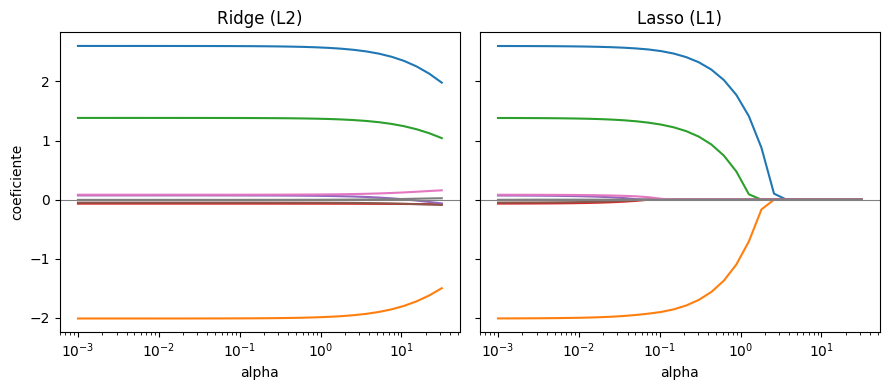

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
for j in range(n_variables):
    ax1.plot(valores_alpha, coef_ridge[:, j])
    ax2.plot(valores_alpha, coef_lasso[:, j])
ax1.set_xscale('log')
ax2.set_xscale('log')
ax1.set_title('Ridge (L2)')
ax2.set_title('Lasso (L1)')
ax1.set_xlabel('alpha')
ax2.set_xlabel('alpha')
ax1.set_ylabel('coeficiente')
ax1.axhline(0, color='gray', lw=0.8)
ax2.axhline(0, color='gray', lw=0.8)
plt.tight_layout()
plt.show()

In [9]:
# Numero de coeficientes exactamente nulos en funcion de alpha
nulos_ridge = np.sum(np.isclose(coef_ridge, 0.0, atol=1e-8), axis=1)
nulos_lasso = np.sum(np.isclose(coef_lasso, 0.0, atol=1e-8), axis=1)
print('Coeficientes nulos con Ridge (max sobre alpha):', nulos_ridge.max())
print('Coeficientes nulos con Lasso (max sobre alpha):', nulos_lasso.max())
print('\nRidge encoge pero rara vez anula; Lasso produce soluciones dispersas.')

Coeficientes nulos con Ridge (max sobre alpha): 0
Coeficientes nulos con Lasso (max sobre alpha): 8

Ridge encoge pero rara vez anula; Lasso produce soluciones dispersas.
